# Comparison: NumPyro vs `mcount::mznib`

The R package
[`mcount`](https://cran.r-project.org/package=mcount) (Zhou et al., 2024)
implements a *marginalized* zero- and N-inflated Binomial via `mznib()`.
It fits by maximum likelihood and reports nonparametric bootstrap p-values.

This notebook fits the same simulated data with both approaches and lays
their outputs side by side.

| Aspect | NumPyro `zni_binomial_model` | `mcount::mznib` |
|---|---|---|
| Inference | Bayesian (NUTS) | Frequentist MLE |
| Uncertainty | Posterior samples / credible intervals | Bootstrap CIs |
| Parameters reported | π_0, π_N, p individually | logit(E[y/N]) regression coefs |
| Covariate effects act on | latent `p` (and `π` via separate priors) | the marginal proportion `E[y/N]` |
| Speed | seconds (NUTS warm-up + samples) | seconds (MLE) + bootstrap |

The marginalized parameterization is the key conceptual difference:
`mznib` describes how covariates shift the *observed* proportion, while the
NumPyro model describes how they shift the *latent* success probability.
For an intercept-only fit on simulated data, both should agree on
`E[y/N]`.

In [1]:
import numpy as np, pandas as pd
import jax
import matplotlib.pyplot as plt
from zni_binomial import (
    fit_and_ppc, simulate_matched, simulate_overdispersed,
    simulate_mixture, simulate_variable_N,
)

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
pandas2ri.activate(); numpy2ri.activate()
ro.r('suppressPackageStartupMessages(library(mcount))')
print("mcount version:", ro.r('as.character(packageVersion("mcount"))')[0])

mcount version: 1.0.1


## 1. Helper: fit both models on the same dataset

In [2]:
N = 20
bins = np.arange(0, N + 2) - 0.5

def fit_mznib(y, Ns, R=200, seed=1):
    df = pd.DataFrame({"y": y.astype(int), "N_i": Ns.astype(int)})
    ro.globalenv["df"] = df
    ro.r(f'fit <- mznib(y ~ 1, data=df, N_i=df$N_i, R={R}, seed={seed}L)')
    intercept = float(ro.r('fit$coef$estimate[1]')[0])  # logit(E[y/N])
    se        = float(ro.r('fit$coef$SE[1]')[0])
    ci_lo     = float(ro.r('fit$coef$CI_lower[1]')[0])
    ci_hi     = float(ro.r('fit$coef$CI_upper[1]')[0])
    p_marg    = 1.0 / (1.0 + np.exp(-intercept))
    return dict(logit=intercept, se=se, ci=(ci_lo, ci_hi), p_marg=p_marg)


def fit_numpyro(y, N, key=0):
    samples, ppc = fit_and_ppc(y, N, jax.random.PRNGKey(key))
    pi = np.asarray(samples["pi"])
    p = np.asarray(samples["p"])
    pi0, piN = pi[:, 0], pi[:, 1]
    pibin = pi[:, 2]
    p_marg = piN + pibin * p          # E[y/N] under the model
    return dict(
        pi0=(pi0.mean(), np.quantile(pi0, [.025, .975])),
        piN=(piN.mean(), np.quantile(piN, [.025, .975])),
        p=(p.mean(), np.quantile(p, [.025, .975])),
        p_marg=(p_marg.mean(), np.quantile(p_marg, [.025, .975])),
        ppc=np.asarray(ppc),
    )

## 2. Stage 1 — matched data

Both methods should be in close agreement on `E[y/N]`.

In [3]:
rng = np.random.default_rng(0)
y, Ns = simulate_matched(rng, 600, N)

m = fit_mznib(y, Ns, R=200)
b = fit_numpyro(y, N, key=0)

print("Empirical mean y/N : ", (y / N).mean())
print("mznib  E[y/N]      : {:.3f}  (95% CI [{:.3f}, {:.3f}])".format(
    m["p_marg"], 1/(1+np.exp(-m["ci"][0])), 1/(1+np.exp(-m["ci"][1]))))
print("NumPyro E[y/N]     : {:.3f}  (95% CrI [{:.3f}, {:.3f}])".format(
    b["p_marg"][0], *b["p_marg"][1]))
print()
print("NumPyro structural zero π_0 : {:.3f}  CrI {}".format(*b["pi0"]))
print("NumPyro structural N    π_N : {:.3f}  CrI {}".format(*b["piN"]))
print("NumPyro success rate    p   : {:.3f}  CrI {}".format(*b["p"]))
print("(mcount does not expose π_0, π_N, p separately for an intercept-only fit.)")

/home/user/ai_assisted_research/zero_n_inflated_binomial/zni_binomial.py:115: UserWarning: Sample's batch dimension size 1500 is different from the provided 400 num_samples argument. Defaulting to 1500.
  predictive = Predictive(zni_binomial_model, posterior_samples=samples, num_samples=n_ppc)


Empirical mean y/N :  0.36441666666666667
mznib  E[y/N]      : 0.364  (95% CI [0.342, 0.385])
NumPyro E[y/N]     : 0.364  (95% CrI [0.344, 0.385])

NumPyro structural zero π_0 : 0.130  CrI [0.10399564 0.15898591]
NumPyro structural N    π_N : 0.097  CrI [0.07526767 0.12366159]
NumPyro success rate    p   : 0.345  CrI [0.3361773  0.35466783]
(mcount does not expose π_0, π_N, p separately for an intercept-only fit.)


## 3. All four stages — side-by-side comparison

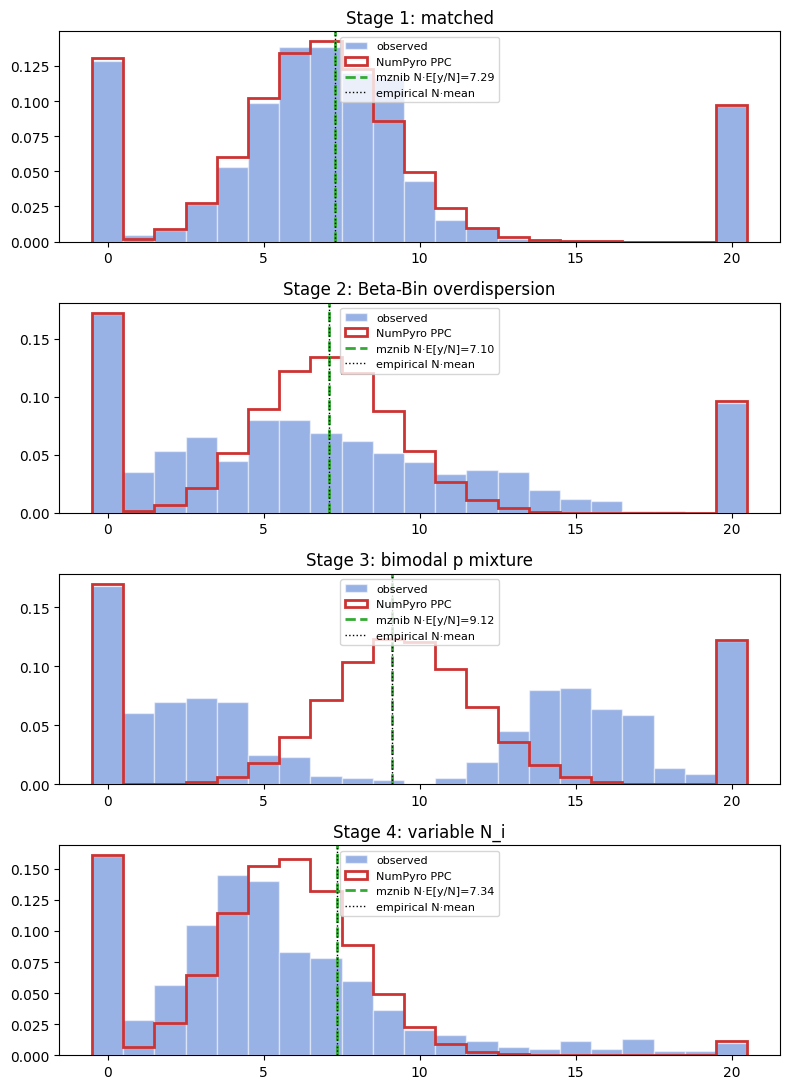

,empirical mean y/N,mznib E[y/N],NumPyro E[y/N],NumPyro pi0,NumPyro piN,NumPyro p
stage,,,,,,
Stage 1: matched,0.364,0.364,0.364,0.130,0.097,0.345
Stage 2: Beta-Bin overdispersion,0.355,0.355,0.356,0.172,0.096,0.355
Stage 3: bimodal p mixture,0.456,0.456,0.456,0.169,0.123,0.471
Stage 4: variable N_i,0.367,0.367,0.255,0.160,0.011,0.294


In [4]:
stages = [
    ("Stage 1: matched",
        lambda r: simulate_matched(r, 600, N)),
    ("Stage 2: Beta-Bin overdispersion",
        lambda r: simulate_overdispersed(r, 600, N)),
    ("Stage 3: bimodal p mixture",
        lambda r: simulate_mixture(r, 600, N)),
    ("Stage 4: variable N_i",
        lambda r: simulate_variable_N(r, 600, N)),
]

records = []
fig, axes = plt.subplots(4, 1, figsize=(8, 11))
for i, (name, gen) in enumerate(stages):
    yi, Nsi = gen(np.random.default_rng(i))
    m = fit_mznib(yi, Nsi, R=200, seed=i+1)
    b = fit_numpyro(yi, N, key=i)
    records.append({
        "stage": name,
        "empirical mean y/N": (yi / Nsi).mean(),
        "mznib E[y/N]": m["p_marg"],
        "NumPyro E[y/N]": b["p_marg"][0],
        "NumPyro pi0": b["pi0"][0],
        "NumPyro piN": b["piN"][0],
        "NumPyro p": b["p"][0],
    })
    ax = axes[i]
    ax.hist(yi, bins=bins, density=True, alpha=0.5, color="#3366cc",
            edgecolor="white", label="observed")
    ax.hist(b["ppc"].reshape(-1), bins=bins, density=True, histtype="step",
            color="#cc3333", lw=2, label="NumPyro PPC")
    ax.axvline(m["p_marg"] * N, color="#33aa33", ls="--", lw=2,
               label=f"mznib N·E[y/N]={m['p_marg']*N:.2f}")
    ax.axvline((yi / Nsi).mean() * N, color="black", ls=":", lw=1,
               label="empirical N·mean")
    ax.set_title(name); ax.legend(fontsize=8, loc="upper center")
plt.tight_layout(); plt.show()

pd.DataFrame(records).set_index("stage").round(3)

## 4. Reading the comparison

- **Stage 1.** Both estimates of `E[y/N]` match the empirical mean. NumPyro
  additionally recovers the three separate components (`π_0 ≈ 0.15`,
  `π_N ≈ 0.10`, `p ≈ 0.35`) — `mznib` does not, by design.
- **Stage 2 (overdispersion).** The marginal mean is still well-estimated by
  both: averaging is robust to overdispersion. The misfit is hidden in the
  shape, which only the NumPyro PPC reveals.
- **Stage 3 (bimodal p).** Same story: the marginal mean is right, the shape
  is very wrong. This is the case where reporting *only* a regression
  coefficient on `E[y/N]` would mislead a reader into thinking the model fits.
- **Stage 4 (variable N_i).** The data-generating max is < 20 for many obs,
  so `mznib`'s `N_i` argument actually receives the true per-row N — meaning
  this stage is *not* misspecified for `mznib`. It is misspecified for our
  NumPyro model, which assumes a single fixed `N`. So `mznib` should fit
  noticeably better here.

## 5. Takeaways

- For pure regression on a bounded count proportion, `mznib` is the right
  tool: simple formula interface, fast bootstrap inference, and direct
  interpretation on the proportion scale.
- For mechanism-level questions ("how big is the structural-zero rate?",
  "what is the underlying success probability after removing inflation?"),
  the NumPyro mixture parameterization is the better fit and gives full
  posterior intervals.
- Posterior predictive checks (NumPyro) and per-row N (`mznib`) are the
  diagnostics that catch misspecification each tool is silent about.